In [1]:
def muon_transport(x0, p0, check=None):
    
    #create new p and x (in m)
    x=Vector3D(x0.x,x0.y,x0.z)/100.
    p=LorentzVector(p0.px,p0.py,p0.pz,p0.e)


    # define constants
    radlen = 0.1002 #radiation length in standard rock in meters 
    # following array from Fig.33.1 in the above pdg link
    de_dx_table = np.array([
       [4.36099173e-03, 6.57627957e-03, 1.46553688e-02, 2.93238579e-02,
        5.09366976e-02, 6.75865273e-02, 8.67095513e-02, 1.10496682e-01,
        1.51635583e-01, 2.09496863e-01, 3.49494345e-01, 7.48013762e-01,
        3.42648204e+00, 1.90808655e+01, 4.11142161e+01, 6.58730230e+01,
        1.04129590e+02, 1.84568406e+02, 3.09987726e+02, 5.00016788e+02,
        8.68548881e+02, 2.46656775e+03, 2.62177522e+04],
       [1.18536913e+02, 7.39534137e+01, 2.49658047e+01, 8.77801477e+00,
        4.00398808e+00, 2.86848732e+00, 2.23823778e+00, 1.84879289e+00,
        1.57121162e+00, 1.43089865e+00, 1.39073536e+00, 1.47822175e+00,
        1.73937479e+00, 2.06338102e+00, 2.28421995e+00, 2.52869476e+00,
        2.85684445e+00, 3.58758012e+00, 4.74984061e+00, 6.60317093e+00,
        1.01621249e+01, 2.57914812e+01, 2.64132901e+02]])
    
    density = 2.65 # g/cm^3
    dz = 10 # m
    tx, ty, energy = p.px/p.pz, p.py/p.pz, p.e

    while x.z < 0.0:
        
        #calculate sigma and dE/dx
        sigma_theta = 0.0136/p.e * np.sqrt(dz/radlen) * (1.+0.038*np.log(dz/radlen)) 
        de_dx = np.interp(energy, de_dx_table[0], de_dx_table[1]) * density / 1000. * 100
        #update position and momentum
        energy -= de_dx*dz
        if energy < 10: return None
        tx += np.random.normal(0, sigma_theta)
        ty += np.random.normal(0, sigma_theta)
        x  += Vector3D(tx*dz, ty*dz, dz)
        
    #get new momentum
    sx, sy = np.sin(np.arctan(tx)), np.sin(np.arctan(ty))
    p = LorentzVector(sx*energy, sy*energy, np.sqrt(1-sx**2-sy**2)*energy, energy)

    # return x,p
    return x*100. # in cm

# Load some packages. Change directory to whichever directory has 'MG5_Output' which is where LHE files are stored
experiments will be used to establish faser1 and 2

In [1]:
import gc
gc.collect()

192

In [2]:
directory_with_MG5_output = '/home/maxfieg/Desktop/RoshanResearch'
directory_with_MG5_output = '/media/maxfieg/Linux1/RoshanResearch'
homefolder = '/home/maxfieg/Desktop/RoshanResearch'
import os
os.chdir(directory_with_MG5_output)

import pdb
import pylhe
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({'font.size':20})
import pylorentz as pyl
def etaf(theta):
    return -np.log(np.tan(theta / 2))


from datetime import datetime as dt
experiments = {
    "FASER"   : {"fnulength": 1.00e2, "rho": 19.3, "material": "W", "posz": 480e2, "lumi":250,
                  "xmin": -.125e2, "xmax": .125e2,"ymin": -.15e2,   "ymax": .15e2,'L_faser':3.5e2,'r_faser':10,'frontoftarget_to_faser_dist':4.5e2 },
    
    "FASER2"  : {"fnulength": 6.60e2, "rho": 19.3, "material": "W", "posz": 620e2, "lumi":3000,
                  "xmin": -.2e2, "xmax": .2e2, "ymin": -.2e2, "ymax": .2e2,'L_faser':20e2,'r_faser':1e2,'frontoftarget_to_faser_dist':20e2+6.6e2  },
    
    "Rock"  : {"fnulength": 100e2, "rho": 2.65, "material": "W", "posz": 380e2, "lumi":250,
              "xmin": -.1e2, "xmax": .1e2, "ymin": -.1e2, "ymax": .1e2,'L_faser':3.5e2,'r_faser':10,'frontoftarget_to_faser_dist':100e2+3.5e2  },
    
    "Rock2"  : {"fnulength": (100+140)*1e2, "rho": 2.65, "material": "W", "posz": 380e2, "lumi":3000,
              "xmin": -1e2, "xmax": 1e2, "ymin": -1e2, "ymax": 1e2,'L_faser':20e2,'r_faser':100,'frontoftarget_to_faser_dist':100e2+140e2+20e2  },
    
    "TAS"  : {"fnulength": 1.8e2, "rho": 8.96, "material": "Cu", "posz": 20e2, "lumi":250,
          "xmin": -.25e2, "xmax": .25e2, "ymin": -.25e2, "ymax": .25e2,'L_faser':3.5e2,'r_faser':10,'frontoftarget_to_faser_dist':460e2  },
    
    "TAS2"  : {"fnulength": 1.8e2, "rho": 8.96, "material": "Cu", "posz": 20e2, "lumi":3000,
          "xmin": -.25e2, "xmax": .25e2, "ymin": -.25e2, "ymax": .25e2,'L_faser':20e2,'r_faser':100,'frontoftarget_to_faser_dist':600e2  }    

}

def plotgm2(ax):
    filelower = 'muon_g-2_lower.txt'
    fileupper = 'muon_g-2_upper.txt'
    
    dfL = pd.read_csv(filelower,delim_whitespace=True,names = ['m','g'])
    dfU = pd.read_csv(fileupper,delim_whitespace=True,names = ['m','g'])
    
    ax.plot(dfL['m'] , dfL['g'],'go--',lw = 3)
    ax.plot(dfU['m'] , dfU['g'],'go--',lw = 3,label = 'g-2')
    
    
def get_xy_samples(emuon,TAS,binwidth=10,nMC = 1000):
    elower = emuon-binwidth/2;eupper = emuon+binwidth/2
    filename = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/SpatialDistributionFiles%s/elower=%1.0f_eupper=%1.0f.npz' %(TAS,elower,eupper)
    
    L = np.load(filename);
    H = L['H'];xctr = L['xctr'];yctr = L['yctr']
    Hflat = H.flatten()
    
    sampled_indices = np.random.choice(np.arange(len(Hflat)), size=nMC, p=Hflat / np.sum(Hflat))

    
    x_choose_ind, y_choose_ind = np.unravel_index(sampled_indices, H.shape)
    x_choose = xctr[x_choose_ind];y_choose = yctr[y_choose_ind]
    return x_choose,y_choose

def get_theta_samples(emuon,binwidth=10,nMC = 1000):
    elower = emuon-binwidth/2;eupper = emuon+binwidth/2
    filename = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/ThetaDistributionFiles/elower=%1.0f_eupper=%1.0f.npz' %(elower,eupper)
    
    L = np.load(filename);
    H = L['H'];thxctr = L['thxctr'];thyctr = L['thyctr']
    Hflat = H.flatten()
    
    sampled_indices = np.random.choice(np.arange(len(Hflat)), size=nMC, p=Hflat / np.sum(Hflat))

    
    x_choose_ind, y_choose_ind = np.unravel_index(sampled_indices, H.shape)
    thx_choose = thxctr[x_choose_ind];thy_choose = thyctr[y_choose_ind]
    return thx_choose,thy_choose


def get_xy_thxthy_samples(TAS,emuon,binwidth=5,nMC = 1000,N_MG5=0):
    plt.rcParams.update({'font.size':10})
    elower = emuon-binwidth;eupper = emuon+binwidth
    filename = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/RThetaDistributionFiles%s/elower=%1.0f_eupper=%1.0f.npz' %(TAS,elower,eupper)
    
    L = np.load(filename);
    H = L['H'];rctr = L['rctr'];thctr = L['thctr']
    Hflat = H.flatten()
    
    sampled_indices = np.random.choice(np.arange(len(Hflat)), size=nMC, p=Hflat / np.sum(Hflat))

    
    r_choose_ind, th_choose_ind = np.unravel_index(sampled_indices, H.shape)
    r_choose = rctr[r_choose_ind];th_choose = thctr[th_choose_ind]
    
    phi_random = np.random.uniform(0,2*np.pi,nMC)
    x = r_choose*np.cos(phi_random);y = r_choose*np.sin(phi_random);
    thx = th_choose*np.cos(phi_random);thy = th_choose*np.sin(phi_random)
    
    if N_MG5!=0:
        
        #how many loops
        x0 = x;y0 = y
        thx0=thx;thy0=thy;
        for iin in np.arange(int(N_MG5/nMC)):
            indices = np.arange(len(x0))
            np.random.shuffle(indices)

            x_shuffled = x[indices]
            y_shuffled = y[indices]
            thx_shuffled = thx[indices]
            thy_shuffled = thy[indices]
            
            x = np.append(x,x_shuffled)
            y = np.append(y,y_shuffled)
            thx = np.append(thx,thx_shuffled)
            thy = np.append(thy,thy_shuffled)
    return x,y,thx,thy

def get_theta_samples_from_xy(x,y,binwidth=10,nMC = 1000):
    r = np.sqrt(x**2+y**2)
    theta = r / (20*1e2)
#     phi_random = np.random.uniform(0,2*np.pi,nMC)
    phi_random = np.arctan(y,x)
    thx_choose , thy_choose = theta*np.cos(phi_random) , theta*np.sin(phi_random)
    return thx_choose,thy_choose

Rock: meanr = 6.17e+00 (norm = 6.17e-01), meanth = 5.09e-03
Rock2: meanr = 6.11e+01 (norm = 6.11e-01), meanth = 2.93e-03


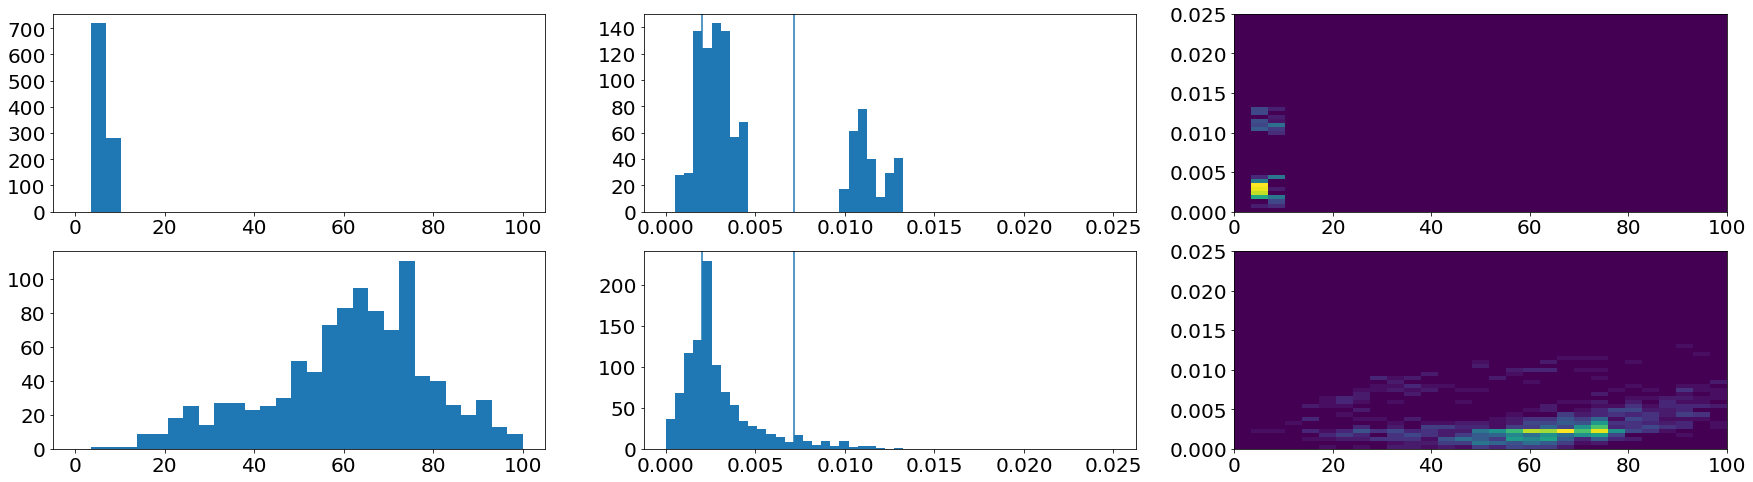

In [12]:
#check distributions
fig,axA = plt.subplots(2,3,figsize = (30,8))
rbins = np.linspace(0,100,30)
thbins = np.linspace(0,0.025,50)
for ax,R in zip(axA,['Rock','Rock2']):
    x,y,thx,thy = get_xy_thxthy_samples(R,305)
    r = np.sqrt(x**2+y**2)
    th = np.sqrt(thx**2+thy**2)
    print('%s: meanr = %1.2e (norm = %1.2e), meanth = %1.2e' %(R,np.mean(r),np.mean(r)/experiments[R]['r_faser'],np.mean(th)))
    ax[0].hist(r,bins = rbins);
    ax[1].hist(th,bins = thbins)
    ax[2].hist2d(r,th,bins = (rbins,thbins))
    
    ax[1].axvline(x = 0.1/50)
    ax[1].axvline(x = 1/140)

# Some preliminary functions
get_events gives the madgraph MC sample and the cross section

dbar gives the decay length of S

sample_exponential is a function to sample the decay length

In [3]:
def get_events(muonenergy,Smass,faser):
    #get mass
    if Smass==2.100000e-01:
        S = '01[-]run_01'
        #if copper
        if 'tas' in faser.lower():
            directory = 'MG5_Output_2mu_copper'
        #if rock
        elif 'rock' in faser.lower():
            directory = 'MG5_Output_2mu_rock'
        #if tungsten
        elif 'faser' in faser.lower():
            directory = 'MG5_Output_2mu_tungsten'
    elif 'rock' in faser.lower():
        directory = 'MG5_Output_Rock'
        S = '[01-11]'
    elif 'faser' not in faser.lower():
        if Smass in [1e-3,5e-3]:
            directory = 'MG5_Output_Copper_EXT3'
            S = '0[1-2]'
            
        elif Smass in [35e-3,45e-3,55e-3,65e-3,110e-3]:
            directory = 'MG5_Output_Copper_EXT2'
            S = '0[1-5]'
        elif (Smass<100e-3)|(Smass>191e-3):
            directory = 'MG5_Output_Copper_EXT'
            S = '0[1-6]'
        else:
            directory = 'MG5_Output_Copper'
            S = '0[1-6]'
    else:
        if Smass>=100e-3:
            directory = 'MG5_Output2'
            S = '0[1-6]'
        else: 
            directory = 'MG5_Output2_EXT'
            S = '0[1-4]'
    #scan_run_01[-]run_01.txt
        
    file0 = '%s/MuonBremS%dGeVScan/Events/scan_run_%s.txt' %(directory,muonenergy,S)
#     print(file0)
    df = pd.read_csv(file0,delim_whitespace=True,names = ['run','mass','crosssec'],skiprows=1)
    runloc=np.where(df['mass']==Smass);runname = df['run'][runloc[0][0]]
    xsec = df['crosssec'][runloc[0][0]]
    
    
    file = '%s/MuonBremS%dGeVScan/Events/%s/unweighted_events.lhe.gz' %(directory, muonenergy,runname)
    events = pylhe.to_awkward(pylhe.read_lhe_with_attributes(file))
    return events,xsec
def dbar(p4S,gs):
#     dbar = 20*1e2 * (p4S.e / 3) * (5e-4 / gs)**2 * (0.1 / p4S.m)**4
    m = p4S.m[0]
    alpha = 1/137
    pi = np.pi
    mmu = 106e-3
    tau = 4*mmu**2/(m**2)
    ftau = np.arcsin(tau**(-1/2))**2
    gamma = alpha**2*gs**2 * m**3 / (64*pi**3*mmu**2) * (tau*(1+(1-tau)*ftau))**2
    dbarcm = p4S.e / m * 1/gamma * 2e-16 * 1e2
    
    return dbarcm

def sample_exponential(lambda_val, size=1,altdecaylength = False,min_val = 0,max_val = np.inf):
    u = np.random.rand(size)
    decay_lengths = -np.log(1 - u) / lambda_val
    
    if altdecaylength:
        nrows,ncols = np.shape(lambda_val)
        decay_lengths = np.array(np.zeros_like(lambda_val))
        for iir in np.arange(nrows):
            uniform_samples = np.random.uniform(min_val,max_val,size = len(lambda_val[iir,:]))

            weights = lambda_val[iir,:] * np.exp(-lambda_val[iir,:]*uniform_samples)
            if np.max(weights)<=0:
                decay_lengths[iir,:] = 0
                continue
            normalized_weights = weights / np.sum(weights)
#             if np.any(np.isnan(normalized_weights)):
                
            weighted_samples = np.random.choice(uniform_samples,p = normalized_weights,size = ncols)
            decay_lengths[iir,:] = weighted_samples
    return decay_lengths

def getLambda(px,py,pz,E):
    vx = px/E
    vy = py/E
    vz = pz/E
    beta_squared = vx**2 + vy**2 + vz**2
    gamma = 1.0 / np.sqrt(1 - beta_squared)
    beta_x = vx
    beta_y = vy
    beta_z = vz

#     return vx,vy,vz,E,gamma
    # Initialize the boost matrix (4, 4, N, n)
    N = np.shape(px)[0];n = np.shape(px)[1]
    boost_matrix = np.zeros((4, 4, N, n))

    # Fill in the boost matrix components
    boost_matrix[0, 0] = gamma
    boost_matrix[0, 1] = -gamma * beta_x
    boost_matrix[0, 2] = -gamma * beta_y
    boost_matrix[0, 3] = -gamma * beta_z

    boost_matrix[1, 0] = -gamma * beta_x
    boost_matrix[1, 1] = 1 + (gamma - 1) * (beta_x**2 / beta_squared)
    boost_matrix[1, 2] = (gamma - 1) * (beta_x * beta_y / beta_squared)
    boost_matrix[1, 3] = (gamma - 1) * (beta_x * beta_z / beta_squared)

    boost_matrix[2, 0] = -gamma * beta_y
    boost_matrix[2, 1] = (gamma - 1) * (beta_y * beta_x / beta_squared)
    boost_matrix[2, 2] = 1 + (gamma - 1) * (beta_y**2 / beta_squared)
    boost_matrix[2, 3] = (gamma - 1) * (beta_y * beta_z / beta_squared)

    boost_matrix[3, 0] = -gamma * beta_z
    boost_matrix[3, 1] = (gamma - 1) * (beta_z * beta_x / beta_squared)
    boost_matrix[3, 2] = (gamma - 1) * (beta_z * beta_y / beta_squared)
    boost_matrix[3, 3] = 1 + (gamma - 1) * (beta_z**2 / beta_squared)
    
    
    return boost_matrix

# Main MC Function with nMC samples as a function of p4S, gS

- Sample over a couple vairables
     - $\gamma_1$ angles $\phi_1,\theta_1$ 
     - $\gamma_2$ angles $\phi_2 = \phi_1+\pi,\theta_2=\pi-\theta_1\$ 
     - S Decay length: d
     - S production point inside of Fasernu: Sproduction(x,y,z)
     
- Then it makes cuts
    - photon1 intercepting faser: locs_geo1
    - photon 2 intercepting faser: locs_geo2
    - S decay happens inside faser: locs_geoS
    - Photon separation passes separation_threshold: locs_sep
    - combined photon energy passes threshold: locs_e
    
It then outputs a number between 0 and 1. If for a given event and coupling (Smomenta and gS) it passes all cuts, it outputs 1 

In [4]:
def decayS_signalVectorized(p4S,gS,faser,emuon,nMC = 10,separation_threshold = 1e-3 , energythreshold = 0,check = None,uniform_xy = False,rotateS = True,rthsampling = True,N_MG5 = 2500,altdecaylength = True):
    if N_MG5==0:
        N_MG5 = len(p4S)
    
    if ('faser' in faser.lower()):# | ('rock' in faser.lower()):
        rotateS = False
        uniform_xy = True
    
    if (nMC<N_MG5) & (False):
        #clip the MG5 Sample
        N_MG5 = nMC
#         p4S = p4S[0:nMC]
        random_indices = np.random.choice(10000, size=nMC, replace=False)
        p4S = p4S[random_indices]
        
    if N_MG5!=0:
        random_indices = np.random.choice(10000, size=N_MG5, replace=False)
        p4S = p4S[random_indices]
        
    experiment = experiments[faser]
    if experiment=='FASER':
        shift = 0
    else:
        shift = experiment['frontoftarget_to_faser_dist']
    
    #get total distance from fasernu to spec
    r_faser = experiment['r_faser']
    faser_spec_coordinate = experiment['posz'] + experiment['frontoftarget_to_faser_dist']
    
    
    #get target length in cm
    zmax = experiment['fnulength']
    
    #get target area
    xmin,xmax = experiment['xmin'],experiment['xmax']
    ymin,ymax = experiment['ymin'],experiment['ymax']
    
    #Production point needs to be early to rotate the beam accordingly:
    #where did interaction happen inside fasernu?
    #could have occurred anywhere, choose random points
    #TODO: make this a non uniform distribtuion. For each muon grab r (or x,y) disribution from text file for that bin. Staitics problems
    Sproductionz = np.random.uniform(experiment['posz'],zmax+experiment['posz'],size = N_MG5)
    if faser =='Rock':
        Sproductionz = np.ones(N_MG5)*((380+50)*1e2)
    elif faser=='Rock2':
        Sproductionz = np.ones(N_MG5)*((380+120)*1e2)
    if uniform_xy:
        Sproductionx = np.random.uniform(xmin,xmax,size = N_MG5)
        Sproductiony = np.random.uniform(ymin,ymax,size = N_MG5)
    else:
        if not rthsampling:
            print('doing not rthsampling')
            x_choose,y_choose = get_xy_samples(emuon,faser,nMC = nMC)
            thx_choose,thy_choose = get_theta_samples_from_xy(x_choose,y_choose,nMC = nMC)
        else:
#             x_choose,y_choose,thx_choose,thy_choose = get_xy_thxthy_samples(faser,emuon,nMC = N_MG5)
            x_choose,y_choose,thx_choose,thy_choose = get_xy_thxthy_samples(faser,emuon,nMC = N_MG5,N_MG5 = 0)

        Sproductionx = x_choose
        Sproductiony = y_choose
            
    
    #Rotate S for muon dispersion
    if rotateS:            
        p0 = p4S.p
        #Rotation not exactly correct
        p4S = p4S.rotateY(thx_choose)
        p4S = p4S.rotateX(thy_choose)
        p1 = p4S.p
        if np.max(np.abs(p0-p1))>1e-3:
            raise('Momentum not conserved after rotation')
    else:
        pass


    
    #grab the mass,convert to array
    mS = p4S.m;mS = np.array(mS[:,0])[:,np.newaxis]
    
    #first in rest frame, chose random angle for first photon
    phi1 = np.random.uniform(0,2*np.pi,size = nMC);phi2 = np.mod(phi1+np.pi,2*np.pi);
    theta1 = np.random.uniform(0,np.pi,size = nMC);theta2 = np.pi - theta1
    
    #in rest frame, photons of equal energy, so each takes half the mass
    E1,E2 = mS / 2, mS / 2
    m1,m2 = 0,0
    eta1 = etaf(theta1);eta2 = etaf(theta2)
    
    #define photons in rest frame
#     return E1,np.ones(nMC)
    photonE,photonm,photoneta,photonphi = np.ones(nMC)*E1 , np.ones(nMC)*m1 , eta1, phi1
#     print('photon e,m,eta,phi shape:',np.shape(photonE),np.shape(photonm),np.shape(photoneta),np.shape(photonphi))

    photon1 = pyl.Momentum4.e_m_eta_phi(photonE,photonm,photoneta,photonphi)
    photon2 = pyl.Momentum4.e_m_eta_phi(np.ones(nMC)*E2 , np.ones(nMC)*m2 , eta2, phi2)
    
#     print('photon shape:',np.shape(photon1))
#     print()
    
        #check that 3 momenta cancels:
    if np.any(np.abs(photon1.p_x+photon2.p_x)/photon1.p_x >1e-5)\
    | np.any(np.abs(photon1.p_y+photon2.p_y)/photon1.p_y >1e-5)\
    | np.any(np.abs(photon1.p_z+photon2.p_z)/photon1.p_z >1e-5):
        print('x:',photon1.p_x,photon2.p_x)
        print('y:',photon1.p_y,photon2.p_y)
        print('z:',photon1.p_z,photon2.p_z)
        pdb.set_trace()
        raise('error, momentum not conserved')
    #3 momenta cancels
    
    #now define S in the lab, grabbing the kinematics
    eS = p4S.e;eS = np.ones(nMC) * np.array(eS[:,0])[:,np.newaxis]
    mS = np.ones(nMC) *np.array(p4S.m[:,0])[:,np.newaxis];
    etaS = np.array(p4S.eta[:,0])[:,np.newaxis];
    phiS = np.array(p4S.phi[:,0])[:,np.newaxis];

#     eS = np.transpose(eS)
#     print('S e,m,eta,phi shape:',np.shape(eS),np.shape(mS),np.shape(etaS),np.shape(phiS))
    
    S_lab = pyl.Momentum4.e_m_eta_phi(eS ,mS ,etaS ,phiS );
#     return S_lab
    ##############################################
    ##############################################
    ##############################################
    
    #a = pyl.Vector4(1,0,0,1)
    # pyl.Momentum4(a).e
    
     #now boost photons to lab farme
#     pdb.set_trace()
    Boost = getLambda(S_lab.p_x,S_lab.p_y,S_lab.p_z,S_lab.e)
    p1_mu = np.einsum('mnij,mij->nij',Boost,photon1)
    p2_mu = np.einsum('mnij,mij->nij',Boost,photon2)
    p1_lab = pyl.Momentum4(pyl.Vector4(p1_mu[0,:,:],p1_mu[1,:,:],p1_mu[2,:,:],p1_mu[3,:,:]))
    p2_lab = pyl.Momentum4(pyl.Vector4(p2_mu[0,:,:],p2_mu[1,:,:],p2_mu[2,:,:],p2_mu[3,:,:]))
    
    #mass check
    m1s = p1_lab.e**2-p1_lab.p_x**2 - p1_lab.p_y**2 - p1_lab.p_z**2
    m2s = p2_lab.e**2-p2_lab.p_x**2 - p2_lab.p_y**2 - p2_lab.p_z**2
    if (np.max(m1s)>1e-9) | (np.max(m2s)>1e-9):
        print(np.max(m1s),np.max(m2s))
        raise('masses are not right')
    
    #write total energy and momenta of photon pair
    e = p1_lab.e+p2_lab.e
    pz = p1_lab.p_z + p2_lab.p_z
    px = p1_lab.p_x + p2_lab.p_x
    py = p1_lab.p_y + p2_lab.p_y
    
    if np.all(np.abs(np.sqrt(e**2-px**2-py**2-pz**2) / mS -1) >1e-3 ):
        raise('momentum not conserved')
        
    #now armed with photon momenta, let's calculate the decay length
    ##will sample from distribution e^-lambda*x where lambda = 1/decay length
    #it is in m so I multiply by 1e2 to get to cm here
    d = dbar(p4S,gS)
    
    #copy d intoa  new axis because it needs to be the right size
    d = np.tile(d,(1,nMC))
    

    #decay_lengths is how far S travelled
    if not altdecaylength:
        decay_lengths = sample_exponential(1/d, size=nMC)
        Pdecay_alt = 1
    else:
        L1Alt = experiment['frontoftarget_to_faser_dist'] - experiment['fnulength']
        L2Alt = experiment['frontoftarget_to_faser_dist'] + experiment['L_faser']
        if np.any(np.isnan(d)):
            print('nans at :',mS,gS,emuon)
        decay_lengths = sample_exponential(1/d, size=nMC,altdecaylength = altdecaylength,min_val = L1Alt,max_val = L2Alt)
        
#         decay_lengths = np.random.uniform(low=L1Alt, high=L2Alt, size=nMC)
        Pdecay_alt = np.exp(-L1Alt / (d)) - np.exp(-L2Alt / (d))

#     print('d:',np.mean(decay_lengths))
        
        
    #where did Sdecay
    #TODO: thx thy distribution in emuon. depends on x,y distribution at first order it does not?
    Sdecayx = Sproductionx[:, np.newaxis] + decay_lengths * np.sin(np.tile(p4S.theta,(1,nMC))) * np.cos(np.tile(p4S.phi,(1,nMC)))
    Sdecayy = Sproductiony[:, np.newaxis] + decay_lengths * np.sin(np.tile(p4S.theta,(1,nMC))) * np.sin(np.tile(p4S.phi,(1,nMC)))
    Sdecayz = Sproductionz[:, np.newaxis] + decay_lengths * np.cos(np.tile(p4S.theta,(1,nMC)))
    
    #now how much length to photons have left to separate?
    #approximate as the length in the z left remaining. Decent approximation. 
    #TODO:ANY BUGS WITH THIS? 
    #LRemainDEPRECATED = L_faser - Sdecayz
    
    # Yes. Can project remaining distance onto z-axis and solve
    LRemain1 = (faser_spec_coordinate - Sdecayz) / (np.cos(p1_lab.theta))
    LRemain2 = (faser_spec_coordinate - Sdecayz) / (np.cos(p2_lab.theta))

    #now propogate photons to get final position
    #photon1
    p1_xf = Sdecayx + LRemain1 * np.sin(p1_lab.theta) * np.cos(p1_lab.phi)
    p1_yf = Sdecayy + LRemain1 * np.sin(p1_lab.theta) * np.sin(p1_lab.phi)
    p1_zf = Sdecayz + LRemain1 * np.cos(p1_lab.theta) 
    #photon2
    p2_xf = Sdecayx + LRemain2 * np.sin(p2_lab.theta) * np.cos(p2_lab.phi)
    p2_yf = Sdecayy + LRemain2 * np.sin(p2_lab.theta) * np.sin(p2_lab.phi)
    p2_zf = Sdecayz + LRemain2 * np.cos(p2_lab.theta) 
    
    #get separation at spectrometer
    separation = np.sqrt( (p1_xf - p2_xf)**2 + (p1_yf - p2_yf)**2 + (p1_zf - p2_zf)**2   )
    #both photons should be at spec
    if np.any(np.abs((p1_zf-p2_zf)) / p1_zf > 1e-3):
        raise('photons have a different z!')
    
    #now gather cuts
    #did photon 1 intercept the detector?
    locs_geo1 = (p1_xf**2 + p1_yf**2) < r_faser**2
    
    #did photon 2 intercept the detector?
    locs_geo2 = (p2_xf**2 + p2_yf**2) < r_faser**2
    
    #did S decay inside decay volume? i.e. is it outside of FASERnu and inside FASEr?
    locs_geoS = (Sdecayx**2 + Sdecayy**2 < r_faser**2) & (Sdecayz > faser_spec_coordinate - experiment['L_faser']) & (Sdecayz < faser_spec_coordinate)
    
    #are photons separated by separation amount?
    locs_sep = separation > separation_threshold
    
    #do photons pass energy threshold
    locs_e = p1_lab.e + p2_lab.e > energythreshold
    etotal = p1_lab.e + p2_lab.e
    
    #did muon intercept all trackers?
    #TODO: NOT CURRENTLY IMPLEMENTED
    if faser!='TAS':
        locs_final = locs_geo1 & locs_geo2 & locs_geoS & locs_sep & locs_e
        locs_final = locs_geo1 & locs_geo2 & locs_geoS
        
    elif faser=='TAS':
        locs_aperature = (np.sqrt(Sproductionx**2 + Sproductiony**2)>3.4/2) & (np.sqrt(Sproductionx**2 + Sproductiony**2)<25)
        locs_final = locs_geo1 & locs_geo2 & locs_geoS & locs_sep & locs_e & locs_aperature[:, np.newaxis]
#         locs_final = locs_geo1 & locs_geo2 & locs_geoS & locs_aperature
        
    elif faser=='TAS2':
        locs_aperature = (np.sqrt(Sproductionx**2 + Sproductiony**2)>6/2) & (np.sqrt(Sproductionx**2 + Sproductiony**2)<25)
        locs_final = locs_geo1 & locs_geo2 & locs_geoS & locs_sep & locs_e & locs_aperature[:, np.newaxis]
#         locs_final = locs_geo1 & locs_geo2 & locs_geoS & locs_aperature
        
        
    fraction_passing = np.sum(locs_final* Pdecay_alt) / (nMC*N_MG5) 
    weight = Pdecay_alt / (nMC*N_MG5);weight = weight[locs_final]
    egamma = etotal[locs_final]
    x1,y1 = p1_xf[locs_final],p1_yf[locs_final]
    x2,y2 = p2_xf[locs_final],p2_yf[locs_final]

    if fraction_passing > 1.0:
        raise('Fraction passing should never be more than 1. Theres a problem')
    
    if check is None:
        return fraction_passing
    elif check == 'geo12':
        return [p1_xf , p1_yf ,p1_zf] , [p2_xf , p2_yf , p2_zf],locs_geo1,locs_geo2,[Sdecayx , Sdecayy , Sdecayz],locs_geoS,Pdecay_alt
    elif check =='gammaspectrum':
        etotal = p1_lab.e + p2_lab.e
        return etotal[locs_final],fraction_passing
    elif check =='paper':
        return fraction_passing, egamma,x1,y1,x2,y2,weight,random_indices,locs_final
    
    
    
gS = np.geomspace(1e-4,10e-4,10);faser='FASER'
gS = 5e-4
# print(gS)
eventnum = np.random.randint(199)
# f = decayS_signalVectorized(p4S,gS,faser,nMC = 6,separation_threshold = 1e-3 , energythreshold = 0,check = None)

In [10]:
# theta = np.ones((10000-1,1))
# p4S.rotateX(theta)
# SignalRate,egamma,x1,y1,x2,y2,weight,emuon_final,thetamuon_final = EventsFromMu(85 , 100e-3 , 1e-2,'FASER',1,nMC = 100,finegrainMG5 = True,check = 'paper')

In [5]:
#For a fixed muon energy, tally up event rate
def EventsFromMu(emuon , mS , gS,faser,Nmuon_emuon,nMC = 100,finegrainMG5 = True,check = ''):
    #first MC sample of Sbrem events
    events,xsec_pb = get_events(emuon,mS,faser)
    
    #now get spectra of S
    p4_full = events.particles.vector
    p4S = p4_full[events.particles.id == 102]
    p4mu_i = p4_full[(events.particles.id == 13) & (events.particles.status==-1)]
    p4mu_f = p4_full[(events.particles.id == 13) & (events.particles.status!=-1)]
    
    
    
    #let's initialize a dictionary that saves muons for different fraction passing
    muonS = np.array([])
    muonthreshold = 0.5;ratemax = 0
    
    masscheck = np.mean(p4S.m)
    if (np.all(p4mu_i.e != emuon)) | (np.abs(masscheck - mS)/masscheck >1e-3):
        print(np.mean(p4mu_i.e),p4S.m)
        print('muon energy or Smass is incorrect, grabbed wrong file')
    
    #initialize Un-normalized signal rate. Need to normalize according to muon flux
    SignalRate_arb = 0
    #now loop through the S spectrum 
    nbins = 35
    weight_array = np.array([])

    photon_spectra = np.array([])
    photon_weight = np.array([])
    photon_spectraavg = np.array([])
    #fine grained option, preferred,
    
    if check=='gammaspectrum':
        ratehere,photonE,(x1,y1),(x2,y2) = decayS_signalVectorized(p4S,gS,faser,emuon,nMC = nMC,separation_threshold = 0 , energythreshold = 0,check =check)
        
    elif check =='paper':
        SignalRate_arb, egamma,x1,y1,x2,y2,weight,random_indices,locs_final = decayS_signalVectorized(p4S,gS,faser,emuon,nMC = nMC,separation_threshold = 0 , energythreshold = 0,check =check)
        
    elif check is None:
        SignalRate_arb = decayS_signalVectorized(p4S,gS,faser,emuon,nMC = nMC,separation_threshold = 0 , energythreshold = 0,check =check)
    
    ZTungsten = 74;ATungsten = 184
    Zrock = 0;Arock = 22;
    Zcopper = 0;Acopper = 63.5
    if 'faser' in faser.lower():
        A = ATungsten
    elif 'rock' in faser.lower():
        A = Arock
    elif 'tas' in faser.lower():
        A = Acopper
        
    #normalization is how many S's are produced (NS = Nmuon * production_probability = Nmuon* FaserNu_Length_cm * (n_tungsten_cm-3 * N_avogaro ) * xsec_Sproduction_pb * 1e-36 cm2/pb * g^2)
    norm =  Nmuon_emuon * (experiments[faser]['fnulength']) * (experiments[faser]['rho']  / A *6.02e23) * (xsec_pb * 1e-36 * gS**2) 
    SignalRate = norm*SignalRate_arb   
    
    weight = weight * norm
    import awkward as ak
    emuonF = ak.to_numpy(p4mu_f.e)
    emuon_final = emuonF[random_indices];
    emuon_final = np.tile(emuon_final,(1,nMC));
    emuon_final = emuon_final[locs_final]
    thetamuonF = ak.to_numpy(p4mu_f.theta)
    thetamuon_final = p4mu_f.theta[random_indices];
    thetamuon_final = np.tile(thetamuon_final,(1,nMC));
    thetamuonfinal = thetamuon_final[locs_final]
    
    #now setup 
    #now get final muon info.
    
    return SignalRate,egamma,x1,y1,x2,y2,weight,emuon_final,thetamuon_final#,Pdecay_alt

In [6]:
# emuon = 15
# mS = 100e-3
# gS = 5e-4
# faser = 'FASER'
# Nmuon_emuon = 1565995
# EventsFromMu(emuon , mS , gS,faser,Nmuon_emuon,nMC = 100)

# loop over muon energies

In [7]:
def EmuonLoop(mS,gS,faser,finegrain=False,eupper = 1000,verbose = False,nMC = 1000,get_photon_spectra = True,NPversion = False):
    if verbose: print('nMC is:',nMC)
    #currently have generated these energies in madgraph
    ##Old Way, sparse Emuon. Let's put in what is now generated
#     emuon_array = np.linspace(50,5050,51)[:-1]
#     emuon_lower = emuon_array-50
#     emuon_upper = emuon_array+50
    emax = 1000
    delta = 10
    emuon_array = np.arange(15,emax,delta)
    emuon_lower = emuon_array-delta/2
    emuon_upper = emuon_array+delta/2
    
    #initialize muon_rate Number. This is per fb-1
    Nmuon_e = np.zeros_like(emuon_array)    
    
    #TODO: I grab rates from .txt files. These are for faserv or faserv2? I assume same for both
    #Easy solution that is not implmented: rescale rate according to larger faser2 area
    for (ie,el) , eu in zip(enumerate(emuon_lower) , emuon_upper):

        #intialize rate here
        N_here = 0
        
        #grab files
        
        if faser=='FASER':
            file_neg = '/media/maxfieg/Linux1/RoshanResearch/results/480m_muons_E>1GeV_minus.txt';dfneg = pd.read_csv(file_neg,delim_whitespace=True,names = ['ecent','Nmuon'])
            file_pos = '/media/maxfieg/Linux1/RoshanResearch/results/480m_muons_E>1GeV_plus.txt';dfpos = pd.read_csv(file_pos,delim_whitespace=True,names = ['ecent','Nmuon'])
        elif faser=='FASER2':
            file_neg = '/media/maxfieg/Linux1/RoshanResearch/results/620m_muons_E>1GeV_minus.txt';dfneg = pd.read_csv(file_neg,delim_whitespace=True,names = ['ecent','Nmuon'])
            file_pos = '/media/maxfieg/Linux1/RoshanResearch/results/620m_muons_E>1GeV_plus.txt';dfpos = pd.read_csv(file_pos,delim_whitespace=True,names = ['ecent','Nmuon'])
            
        elif faser=='TAS':
            file_neg = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/MuonFlux_inner10cm_neg_wAp.txt';dfneg = pd.read_csv(file_neg,delim_whitespace=True,names = ['ecent','Nmuon'])
            file_pos = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/MuonFlux_inner10cm_pos_wAp.txt';dfpos = pd.read_csv(file_pos,delim_whitespace=True,names = ['ecent','Nmuon'])
        elif faser=='TAS2':
            file_neg = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/MuonFlux_TAS2_neg.txt';dfneg = pd.read_csv(file_neg,delim_whitespace=True,names = ['ecent','Nmuon'])
            file_pos = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/MuonFlux_TAS2_pos.txt';dfpos = pd.read_csv(file_pos,delim_whitespace=True,names = ['ecent','Nmuon'])
        
        elif faser=='Rock':
            file_neg = '/media/maxfieg/Linux1/RoshanResearch/results/430m_muons_E>1GeV_minus.txt';dfneg = pd.read_csv(file_neg,delim_whitespace=True,names = ['ecent','Nmuon'])
            file_pos = '/media/maxfieg/Linux1/RoshanResearch/results/430m_muons_E>1GeV_plus.txt';dfpos = pd.read_csv(file_pos,delim_whitespace=True,names = ['ecent','Nmuon'])
        elif faser=='Rock2':
            file_neg = '/media/maxfieg/Linux1/RoshanResearch/results/500m_muons_E>1GeV_minus.txt';dfneg = pd.read_csv(file_neg,delim_whitespace=True,names = ['ecent','Nmuon'])
            file_pos = '/media/maxfieg/Linux1/RoshanResearch/results/500m_muons_E>1GeV_plus.txt';dfpos = pd.read_csv(file_pos,delim_whitespace=True,names = ['ecent','Nmuon']) 
        
        #find indces of mu^- such that we can accumulate the flux
#         print(el)
        loc0 = np.min(np.where(dfneg['ecent'] > el));
        loc1 = np.max(np.where(dfneg['ecent'] < eu))
        N_here += np.sum(dfneg['Nmuon'][loc0:loc1+1])
#         pdb.set_trace()
        #find indeces of mu^+ such that we can accumulate the flux
        loc0 = np.min(np.where(dfpos['ecent'] > el));
        loc1 = np.max(np.where(dfpos['ecent'] < eu))
        N_here += np.sum(dfpos['Nmuon'][loc0:loc1+1])
        
        Nmuon_e[ie] = N_here

    
    #rescale with lumi
    lumi = experiments[faser]['lumi']
    Nmuon_e *= lumi
    
    eventrate = 0
    e_finalmuon = np.array([])
    
    counter = -1
    soft_add_count = 0
    soft_threshold = 1e-2
    soft_add_threshold = 3
    max_rate,emuon_max = 0,0
    
    if NPversion:
        muonSTotal = np.array([])
        photonspectraTotal = np.array([])
        x1Total = np.array([]);y1Total = np.array([]);
        x2Total = np.array([]);y2Total = np.array([]);
        locs_finalTotal = np.array([]);
        weight_arrayTotal = np.array([])
        emuonfinal_total = np.array([])
        thetamuonfinal_total = np.array([])
    else:
        muonSTotal = []
        photonspectraTotal = []
        x1Total = [];y1Total = [];
        x2Total = [];y2Total =[];
        locs_finalTotal = [];
        weight_arrayTotal = []
        emuonfinal_total = []
        thetamuonfinal_total = []
    
    for emuon,Nmuon_ei in zip(emuon_array , Nmuon_e):
        if emuon>1e3:
            continue    
        if Nmuon_ei==0:
            continue
        counter +=1
        
        #this is true
        if get_photon_spectra:
            #this is for tas and fasernu
            ratehere,egamma,x1,y1,x2,y2,weight_array,emuonfinal,thetamuonfinal = EventsFromMu(emuon , mS , gS,faser,Nmuon_emuon = Nmuon_ei,nMC = nMC,check = 'paper')
            #for rock
            #I know have a flux file that I am looping through
            
            if (ratehere==0) & (len(x1)==0):
                continue
            if len(x1)==0:
                print('problem with rates')
                print('x1=',x1)
                print('weightarray = ',weight_array)
                print('emuonfinal=',emuonfinal)
#                 raise('error')
                
            if NPversion:
                photonspectraTotal=np.append(photonspectraTotal,egamma)
                x1Total = np.append(x1Total,x1);
                y1Total = np.append(y1Total,y1);
                x2Total = np.append(x2Total,x2);
                y2Total = np.append(y2Total,y2);
    #             locs_finalTotal = np.append(locs_finalTotal,locs_final);
                weight_arrayTotal = np.append(weight_arrayTotal,weight_array);
                emuonfinal_total = np.append(emuonfinal_total,emuonfinal)
                thetamuonfinal_total = np.append(thetamuonfinal_total,thetamuonfinal)
            else:
                photonspectraTotal.extend(egamma.tolist())
                x1Total.extend(x1.tolist())
                y1Total.extend(y1.tolist())
                x2Total.extend(x2.tolist())
                y2Total.extend(y2.tolist())
                weight_arrayTotal.extend(weight_array.tolist())
                emuonfinal_total.extend(emuonfinal.tolist())
                thetamuonfinal_total.extend(thetamuonfinal.tolist())
        
        else:
            ratehere = EventsFromMu(emuon , mS , gS,faser,Nmuon_emuon = Nmuon_ei,nMC = nMC)
        
        if ratehere > max_rate:
            emuon_max = emuon
            max_rate = ratehere
            
        #add to toal rate
        eventrate += ratehere
    
        if (np.mod(counter,10)==0) & (verbose):
            print('For emuon = %1.2f , rate here = %1.2e, total rate = %1.2e' %(emuon,ratehere,eventrate))
        #now let's count if it makes a big difference

    if verbose:
        print('##########')
    
    if get_photon_spectra:
        if NPversion:
            pass
        else:
            eventrate = np.array(eventrate)
            photonspectraTotal = np.array(photonspectraTotal)
            x1Total = np.array(x1Total)
            y1Total = np.array(y1Total)
            x2Total = np.array(x2Total)
            y2Total = np.array(y2Total)
            weight_arrayTotal = np.array(weight_arrayTotal)
            emuonfinal_total = np.array(emuonfinal_total)
            thetamuonfinal_total = np.array(thetamuonfinal_total)
            
        print('Breaking out. emuon=%1.2f, emuon_max = %1.2f, ratehere = %1.2f, maxrate = %1.2f, total=%1.2f, mS = %1.2f, gS = %1.2e,Nphotons = %1.0f,Unique_photonE = %d' %(emuon,emuon_max,ratehere,max_rate,eventrate,mS,gS,len(photonspectraTotal),len(np.unique(photonspectraTotal))))
        return eventrate,photonspectraTotal,x1Total,y1Total,x2Total,y2Total,weight_arrayTotal,emuonfinal_total,thetamuonfinal_total
    else:
        return eventrate
        

In [7]:
#rock
# eventrate = EmuonLoop(100e-3,4e-3,'Rock',verbose = False)
# eventrate = EmuonLoop(100e-3,4e-3,'FASER',verbose = False)

In [10]:
# eventrate = EmuonLoop(100e-3,0.6e-3,'Rock',verbose = False)
# eventrate = EmuonLoop(100e-3,0.6e-3,'FASER',verbose = False)

In [ ]:
emuon,mS,gS,faser,nMu,Nmuon_emuon
EventsFromMu(emuon , mS , gS,faser,Nmuon_emuon,nMC = 100,finegrainMG5 = True,check = '')

# Check All Space

# Multiprocessing

In [8]:
import concurrent.futures
import numpy as np
import time

def process_single(gS, mS):
#     print(nMC,target)
    eventrate,photonspectraTotal,x1Total,y1Total,x2Total,y2Total,weight_arrayTotal,emuonfinal,thetamuonfinal = EmuonLoop(mS, gS, target, verbose=False, nMC=nMC)
#     print(EmuonLoop(mS, gS, target, verbose=False, nMC=nMC))
    return eventrate,photonspectraTotal,x1Total,y1Total,x2Total,y2Total,weight_arrayTotal,emuonfinal,thetamuonfinal

def get_N_array(mS, gS_array):
    # Use ProcessPoolExecutor with max_workers=8 to limit to 8 cores
#     print(mS,gS_array)
    with concurrent.futures.ProcessPoolExecutor(max_workers=7) as executor:
        results = list(executor.map(process_single, gS_array, [mS] * len(gS_array)))
        
    event_array = [r[0] for r in results]
    Egamma = [r[1] for r in results]
    x1 = [r[2] for r in results]
    y1 = [r[3] for r in results]
    x2 = [r[4] for r in results]
    y2 = [r[5] for r in results]
    weights = [r[6] for r in results]
    emuon = [r[7] for r in results]
    thetamuon = [r[8] for r in results]
    
    return np.array(event_array),Egamma,x1,y1,x2,y2,weights,emuon,thetamuon





#let's check the statistics and memory of 8 workers and nMC = 500
#memory barely moves
#nMC = 100 --> 7 minutes
def get_file(mS_array,gS_array,label,save = True):
    event_space = np.zeros((len(mS_array) , len(gS_array)))
#     print('m,g=',mS_array,gS_array)
    
    for iim,mS in enumerate(mS_array):
        ts = time.time()
        import gc
        gc.collect()
        event_array,Egamma,x1,y1,x2,y2,weights,emuon,thetamuon = get_N_array(mS,gS_array)
        event_space[iim,:] = event_array

        for iig,gS in enumerate(gS_array):
            filename = 'NewReach/%s/Alt_Kin_mS=%1.2eMeV_gS=%1.3e_%d_event_array_%s_nMC=%d_%d.npz'%(target,mS,gS,iig,target,nMC,label);
            if save:
                np.savez(filename,mS = mS,gS = gS_array[iig],Nevents = event_array[iig],Egamma = Egamma[iig],x1=x1[iig],y1=y1[iig],x2=x2[iig],y2=y2[iig],weights=weights[iig],emuon = emuon[iig],thetamuon = thetamuon[iig])
    te = time.time()
#     print('ended at :',te, '| deltaT=',te-ts)
#     print('event_array=',event_array)
        
    #now save the whole thing
    print(event_space)
    filename = 'Reach/event_space_%s.npz'%target;print('bigfile:',filename) 
#     np.savez(filename,mS_array = mS_array,gS_array = gS_array,event_space = event_space)
    


mS_array = np.array([10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3])
# mS_array = np.array([1])
target = 'TAS2'
gS_array = np.geomspace(0.08e-3,5e-2,16)
# get_file(mS_array,gS_array)

target = 'TAS'
gS_array = np.geomspace(0.1e-3,5e-2,16)
# get_file(mS_array,gS_array)
# x1Total

In [19]:
import gc
df = pd.read_csv('/media/maxfieg/Linux1/RoshanResearch/MG5_Output_Rock/MuonBremS15GeVScan/Events/scan_run_[01-11].txt',skiprows = 1,delim_whitespace=True,names= ['a','b','c'])
np.array(df['b'])

array([0.01 , 0.025, 0.035, 0.05 , 0.075, 0.1  , 0.12 , 0.14 , 0.16 ,
       0.18 , 0.198])

In [9]:
nMC = 5
import time
for ii in np.arange(1):
    #first TAS2
    mS_array = np.array([35e-3,45e-3,55e-3,65e-3,110e-3,10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3,2.100000e-01 ])
    target = 'TAS2'
    gS_array = np.geomspace(0.1e-4,10e-2,16)
#     print(target,nMC,'m,g=',mS_array,gS_array)
#     get_file(mS_array,gS_array,label = ii)
    import gc
    gc.collect()
    
    #now TAS
    #last complete run was 0.2 = 0.198 for nMC=5
    mS_array = np.array([10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3,35e-3,45e-3,55e-3,65e-3,110e-3,2.100000e-01 ])
    target = 'TAS'
    gS_array = np.geomspace(0.1e-3,10e-2,16)
#     print(target,nMC,'m,g=',mS_array,gS_array)
#     get_file(mS_array,gS_array,label = ii)

    gc.collect()
    #now faser
 

    #now faser
    mS_array = np.array([10e-3,25e-3,50e-3,75e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,2.100000e-01 ])
    target = 'FASER'
    gS_array = np.geomspace(0.5e-3,10e-2,16)
#     print(target,nMC,'m,g=',mS_array,gS_array)
#     get_file(mS_array,gS_array,label = ii)
    
    target = 'FASER2'
    gS_array = np.geomspace(0.1e-4,10e-2,16)
    mS_array = np.array([10e-3,25e-3,50e-3,75e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,2.100000e-01 ])
#     print(target,nMC,'m,g=',mS_array,gS_array)
#     get_file(mS_array,gS_array,label = ii)   

    nMC = 7
    mS_array = np.array([0.01 , 0.025, 0.035, 0.05 , 0.075, 0.1  , 0.12 , 0.14 , 0.16 ,0.18 , 0.198,2.100000e-01 ])
    mS_array = np.array([2.100000e-01 ])
    target = 'Rock2'
    gS_array = np.geomspace(0.1e-4,10e-2,16)
    print(target,nMC,'m,g=',mS_array,gS_array)
    get_file(mS_array,gS_array,label = ii)     
    
    
    mS_array = np.array([0.01 , 0.025, 0.035, 0.05 , 0.075, 0.1  , 0.12 , 0.14 , 0.16 ,0.18 , 0.198,2.100000e-01 ])
    target = 'Rock'
    gS_array = np.geomspace(0.5e-3,10e-2,16)
    print(target,nMC,'m,g=',mS_array,gS_array)
    get_file(mS_array,gS_array,label = ii) 


Rock2 7 m,g= [0.21] [1.00000000e-05 1.84784980e-05 3.41454887e-05 6.30957344e-05
 1.16591440e-04 2.15443469e-04 3.98107171e-04 7.35642254e-04
 1.35935639e-03 2.51188643e-03 4.64158883e-03 8.57695899e-03
 1.58489319e-02 2.92864456e-02 5.41169527e-02 1.00000000e-01]
Breaking out. emuon=995.00, emuon_max = 35.00, ratehere = 0.00, maxrate = 0.00, total=0.02, mS = 0.21, gS = 1.85e-05,Nphotons = 104180,Unique_photonE = 74569
Breaking out. emuon=995.00, emuon_max = 35.00, ratehere = 0.00, maxrate = 0.01, total=0.20, mS = 0.21, gS = 3.41e-05,Nphotons = 104292,Unique_photonE = 74630
Breaking out. emuon=995.00, emuon_max = 245.00, ratehere = 2.07, maxrate = 6.83, total=303.93, mS = 0.21, gS = 3.98e-04,Nphotons = 97209,Unique_photonE = 68103
Breaking out. emuon=995.00, emuon_max = 35.00, ratehere = 0.00, maxrate = 0.00, total=0.00, mS = 0.21, gS = 1.00e-05,Nphotons = 104129,Unique_photonE = 74536
Breaking out. emuon=995.00, emuon_max = 65.00, ratehere = 0.00, maxrate = 0.12, total=2.00, mS = 0.21

In [12]:
experiments['Rock'],experiments['Rock2'],50+1.5,120+10

({'fnulength': 10000.0,
  'rho': 2.65,
  'material': 'W',
  'posz': 38000.0,
  'lumi': 250,
  'xmin': -10.0,
  'xmax': 10.0,
  'ymin': -10.0,
  'ymax': 10.0,
  'L_faser': 350.0,
  'r_faser': 10,
  'frontoftarget_to_faser_dist': 10450.0},
 {'fnulength': 24000.0,
  'rho': 2.65,
  'material': 'W',
  'posz': 38000.0,
  'lumi': 3000,
  'xmin': -100.0,
  'xmax': 100.0,
  'ymin': -100.0,
  'ymax': 100.0,
  'L_faser': 2000.0,
  'r_faser': 100,
  'frontoftarget_to_faser_dist': 26000.0},
 51.5,
 130)

In [13]:
#for high stats
target = 'Rock'
nMC = 51
mS_array = np.array([100e-3])
gS_array = np.array([6.3100e-4])
get_file(mS_array,gS_array,label = 1)

mS_array = np.array([35e-3])
gS_array = np.array([2.5119e-3])
get_file(mS_array,gS_array,label = 1)

Breaking out. emuon=995.00, emuon_max = 25.00, ratehere = 0.00, maxrate = 0.01, total=0.08, mS = 0.10, gS = 6.31e-04,Nphotons = 135294,Unique_photonE = 75465
[[0.07802276]]
bigfile: Reach/event_space_Rock.npz
Breaking out. emuon=995.00, emuon_max = 15.00, ratehere = 0.00, maxrate = 0.17, total=1.31, mS = 0.04, gS = 2.51e-03,Nphotons = 136062,Unique_photonE = 76189
[[1.31259919]]
bigfile: Reach/event_space_Rock.npz


In [9]:
#for high stats
target = 'Rock'
nMC = 51
mS_array = np.array([100e-3])
gS_array = np.array([6.3100e-4])
get_file(mS_array,gS_array,label = 1)

mS_array = np.array([35e-3])
gS_array = np.array([2.5119e-3])
get_file(mS_array,gS_array,label = 1)

Breaking out. emuon=995.00, emuon_max = 55.00, ratehere = 0.00, maxrate = 0.00, total=0.03, mS = 0.10, gS = 6.31e-04,Nphotons = 112006,Unique_photonE = 62248
[[0.03452313]]
bigfile: Reach/event_space_Rock.npz
Breaking out. emuon=995.00, emuon_max = 25.00, ratehere = 0.00, maxrate = 0.04, total=0.56, mS = 0.04, gS = 2.51e-03,Nphotons = 113009,Unique_photonE = 62796
[[0.55581392]]
bigfile: Reach/event_space_Rock.npz


In [12]:
#for high stats
target = 'TAS'
nMC = 50
mS_array = np.array([100e-3])
gS_array = np.array([6.3100e-4])
get_file(mS_array,gS_array,label = 1)

mS_array = np.array([35e-3])
gS_array = np.array([2.5119e-3])
get_file(mS_array,gS_array,label = 1)

Breaking out. emuon=995.00, emuon_max = 65.00, ratehere = 0.00, maxrate = 0.22, total=2.09, mS = 0.10, gS = 6.31e-04,Nphotons = 7098,Unique_photonE = 575
[[2.08835901]]
bigfile: Reach/event_space_TAS.npz
Breaking out. emuon=995.00, emuon_max = 55.00, ratehere = 0.00, maxrate = 21.08, total=108.84, mS = 0.04, gS = 2.51e-03,Nphotons = 7590,Unique_photonE = 621
[[108.84002228]]
bigfile: Reach/event_space_TAS.npz


In [75]:
#5 mins for 500
#30 mins for 5000
#16 mins for 2500
import time#.time()
ts = time.time()
nMC = 10
eventrate,photonspectraTotal,x1Total,y1Total,x2Total,y2Total,weight_arrayTotal,emuonfinal,thetamuonfinal = EmuonLoop(100e-3, 3e-3, 'TAS', verbose=True, nMC=nMC)
te = time.time()
print(nMC,(te-ts)/60,' mins')

nMC is: 10
For emuon = 15.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 115.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 215.00 , rate here = 4.49e-05, total rate = 4.59e-05


KeyboardInterrupt: 

In [8]:
#just 1 file
nMC = 500
target = 'TAS'
mS_array = np.array([100e-3])
gS_array = np.array([0.00158489])
get_file(mS_array,gS_array,label = 0)

nMC = 500
target = 'TAS2'
mS_array = np.array([100e-3])
gS_array = np.array([0.00158489])
get_file(mS_array,gS_array,label = 0)

m,g= [0.1] [0.00158489]
0.1 [0.00158489]
500 TAS
ended at : 1728070057.8455174 | deltaT= 2162.6043224334717
event_array= [1.0023551]
[[1.0023551]]
bigfile: Reach/event_space_TAS.npz
m,g= [0.1] [0.00158489]
0.1 [0.00158489]
500 TAS2
ended at : 1728072374.684021 | deltaT= 2316.747559785843
event_array= [1271.99801358]
[[1271.99801358]]
bigfile: Reach/event_space_TAS2.npz


# plotting 

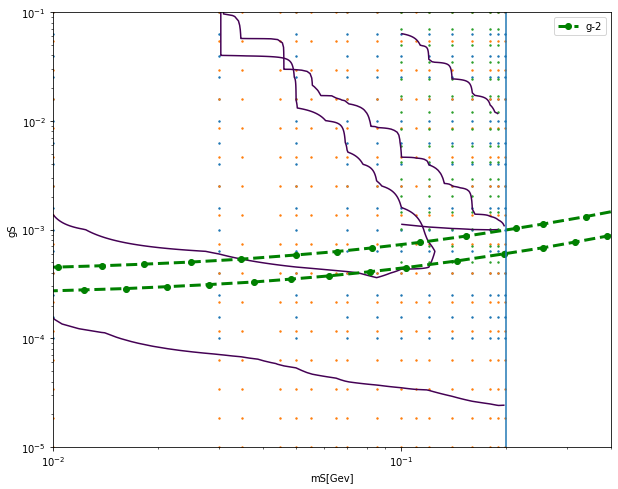

In [30]:
def plotgm2(ax):
    filelower = 'muon_g-2_lower.txt'
    fileupper = 'muon_g-2_upper.txt'

    dfL = pd.read_csv(filelower,delim_whitespace=True,names = ['m','g'])
    dfU = pd.read_csv(fileupper,delim_whitespace=True,names = ['m','g'])

    ax.plot(dfL['m'] , dfL['g'],'go--',lw = 3)
    ax.plot(dfU['m'] , dfU['g'],'go--',lw = 3,label = 'g-2')


    
    ax.set_xlim(1e-2,400e-3)
    ax.axvline(x = 200e-3)
    ax.set_xlabel('mS[Gev]')
    ax.set_ylabel('gS')
    ax.legend()
    return fig, ax
def make_event_space(E,mS_array,gS_array,nMC = 5,Ecut = 0,fig = '',ax = '',method='cubic',NN = 500):
    event_space = np.zeros((len(mS_array),len(gS_array)))
    for iim,mS in enumerate(mS_array):
        for iig, gS in enumerate(gS_array):
            filename = 'NewReach/%s/Alt_Kin_mS=%1.2eMeV_gS=%1.3e_%d_event_array_%s_nMC=%d_%d.npz'%(E,mS,gS,iig,E,nMC,0)
            #np.savez(filename,mS = mS,gS = gS_array[iig],Nevents = event_array[iig],Egamma = Egamma[iig],x1=x1[iig],y1=y1[iig],x2=x2[iig],y2=y2[iig],weights=weights[iig])
            L = np.load(filename)
            N = L['Nevents'];weights = L['weights'];Egamma = L['Egamma']
            if np.sum(weights)==0:
                N = 1e-20
            else:
                locs_e = Egamma>Ecut
                N = N * np.sum(weights[locs_e]) / np.sum(weights)
                if np.isnan(N):
                    N = 1e-20
            if N==0:
                N = 1e-20
            event_space[iim,iig] = N
    from scipy.interpolate import interp2d
    from scipy.interpolate import RegularGridInterpolator
    
#     fun = interp2d(mS_array,gS_array,np.transpose(event_space),kind = 'cubic')
    logg = np.log10(gS_array)
    fun = RegularGridInterpolator((mS_array, gS_array), event_space, method='linear')
#     logfun = RegularGridInterpolator((mS_array, gS_array), np.log(event_space), method=method, bounds_error=True, fill_value=1e-5)
    
    xnew = np.linspace(np.min(mS_array),np.max(mS_array),NN)
    ynew = np.geomspace(np.min(gS_array),np.max(gS_array),NN)
#     znew = fun(xnew,ynew)
    x_new_grid, y_new_grid = np.meshgrid(xnew, ynew)
    
    points = np.array([x_new_grid.ravel(), y_new_grid.ravel()]).T
#     return logfun,xnew,ynew,event_space
    znew = fun(points).reshape(NN, NN)
#     logfun(points)
#     outputlog = logfun(points)
#     outputlog[np.isnan(outputlog)] = 
#     znewlog = np.exp(logfun(points)).reshape(NN, NN)
    znewlog = fun(points).reshape(NN, NN)

#     plt.imshow(znew, extent=(np.min(mS_array),np.max(mS_array),np.min(gS_array),np.max(gS_array)), origin='lower', alpha=0.5, cmap='viridis')    
#     plt.yscale('log')
#     plt.xscale('log')
    if fig=='':
        fig,ax = plt.subplots(1,1,figsize = (10,8))
    X,Y = np.meshgrid(mS_array,gS_array)
#     ax.scatter(X,Y,marker = 'o')
#     X,Y = np.meshgrid(xnew,ynew)
    ax.scatter(X,Y,s = 2)
    
#     plt.contour(xnew, ynew, znew, levels=[3], cmap='viridis')  # Contour plot
    ax.contour(xnew, ynew, znewlog, levels=[np.log(3)], cmap='viridis')  # Contour plot

    ax.set_yscale('log')
    ax.set_xscale('log')
    

#     return logfun
for ECut in [0]:
    for sepcut in[0]:
        E = 'TAS'    
        label = '%s: E>%1.1f' , 
        fig,ax = plt.subplots(1,1,figsize = (10,8))
        mS_array = np.array([10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3])
        gS_array = np.geomspace(0.1e-3,10e-2,16)
        make_event_space(E,mS_array,gS_array,fig=fig,ax= ax)
        
        E = 'TAS2'    
        mS_array = np.sort(np.array([35e-3,45e-3,55e-3,65e-3,110e-3,10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3]))
        gS_array = np.geomspace(0.1e-4,10e-2,16)
        make_event_space(E,mS_array,gS_array,nMC = 5,Ecut = 0,fig=fig,ax= ax,NN = 100,method = 'linear')

        E = 'FASER'    
        mS_array = np.array([1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1])
        gS_array = np.geomspace(0.5e-3,10e-2,16)
        make_event_space(E,mS_array,gS_array,fig=fig,ax= ax)

        plotgm2(ax)


In [176]:
plotgm2(ax)

(array([0.198]), array([0.1]))

In [194]:
np.log(0)

/tmp/ipykernel_28671/2933082444.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


-inf

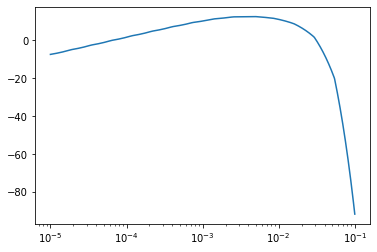

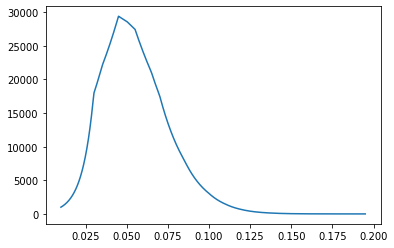

In [153]:
#np.exp(fun(points)).reshape(NN, NN)
N = 10000
mS_array = np.linspace(40*1e-3,195e-3,N)
gS_array = np.geomspace(1e-5,1e-1,N)
for m in [40e-3]:
    points = (m,gS_array)
    y = np.log(np.exp(fun(points)))
#     y = fun(points)
    plt.plot(gS_array,y)
#     plt.yscale('log')
    plt.xscale('log')

plt.figure()
mS_array = np.linspace(10*1e-3,195e-3,N)
points = (mS_array,1e-3)
y = np.exp(fun(points))
plt.plot(mS_array,y)
# plt.yscale('log')
# plt.xscale('log')

In [98]:
mS_array = np.array([10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3])
gS_array = np.geomspace(0.1e-3,10e-2,16)
gS_array

array([0.0001    , 0.00015849, 0.00025119, 0.00039811, 0.00063096,
       0.001     , 0.00158489, 0.00251189, 0.00398107, 0.00630957,
       0.01      , 0.01584893, 0.02511886, 0.03981072, 0.06309573,
       0.1       ])

In [ ]:
def get_photon_spectra(mS,gS):
    plt.rcParams.update({'font.size':15})
    plt.rcParams.update({'font.size':15});
#     filenames = ['/media/maxfieg/Linux1/RoshanResearch/NewReach/TAS/Alt_Kin_mS=%1.2eMeV_gS=%1.3e_4_event_array_TAS_nMC=250_0.npz' %(mS,gS)]
    filenames = ['/media/maxfieg/Linux1/RoshanResearch/NewReach/TAS/Alt_Kin_mS=1.00e-01MeV_gS=1.585e-03_0_event_array_TAS_nMC=50_0.npz']
    filenames = ['/media/maxfieg/Linux1/RoshanResearch/NewReach/TAS2/Alt_Kin_mS=1.00e-01MeV_gS=1.823e-03_13_event_array_TAS2_nMC=50_0.npz']
    bins = np.linspace(1,300,50)
    bins = 10
    ebins = np.geomspace(80,1000,20)
    dbins = np.geomspace(1e-2,15,20)
    Etotal = np.array([])
    Wtotal = np.array([])
    fig,ax = plt.subplots(1,3,figsize = (30,8))
    fig2,ax2 = plt.subplots(1,1,figsize = (10,8))

    for filename in filenames:
#     np.savez(filename,mS = mS,gS = gS_array[iig],Nevents = event_array[iig],Egamma = Egamma[iig],x1=x1[iig],y1=y1[iig],x2=x2[iig],y2=y2[iig],weights=weights[iig])
        plt.figure()
        L = np.load(filename)
        E = L['Egamma'];W = L['weights'];N = L['Nevents']
        x1,x2,y1,y2 = L['x1'],L['x2'],L['y1'],L['y2']
        Delta = np.sqrt((x1-x2)**2 + (y1-y2)**2)
        print(np.sum(W),N)
#         Etotal = np.append(Etotal)
#         print(N)
#         print(E)
        print('w',np.shape(W),np.shape(x1))
        print('unique E over E',len(np.unique(E)) / len(E),'naive guess:',500/500**2 )
        print('unique x over x',len(np.unique(x1)) / len(x1) )
        print('unique E',len(np.unique(E)))
        ax[0].hist(E,weights = W,bins = ebins)
        ax[1].hist(Delta,weights = W,bins = dbins)
        ax[2].hist2d(E,Delta,weights = W,bins = (ebins,dbins))
        
        for a in ax:
            a.set_xscale('log')
        ax[2].set_yscale('log')
        print(np.sum(E*W) / np.sum(W))
        
#         for xa,xb,ya,yb in zip(x1,x2,y1,y2):
#             ax2.plot([xa,xb],[ya,yb],ls = '--',alpha = 0.3,color = 'blue')
    ax2.plot(np.array([x1, x2]), np.array([y1, y2]), ls='--', alpha=0.3, color='blue')
    ax2.scatter(x1, y1, color='red', marker='o', s=1)  # Markers at the start points
    ax2.scatter(x2, y2, color='green', marker='o', s=1)  # Markers at the end points


    
    ax[0].set_xlabel(r'$E_{\gamma \gamma}$[GeV]')
    ax[1].set_xlabel(r'$\Delta_{\gamma \gamma}$[cm]')
    ax[1].set_xlabel(r'$E_{\gamma \gamma}$[GeV]')
    ax[2].set_ylabel(r'$\Delta_{\gamma \gamma}$[cm]')
    fig.suptitle('mS = 100MeV, gS = 1e-3')
get_photon_spectra(100e-3,0.00158489)

753.2456134220735 753.2456134220711
w (774488,) (774488,)
unique E over E 0.06519016434082904 naive guess: 0.002
unique x over x 1.0
unique E 50489
350.57449656962376


# plotting

(<Figure size 720x576 with 1 Axes>, <Axes: xlabel='mS[Gev]', ylabel='gS'>)

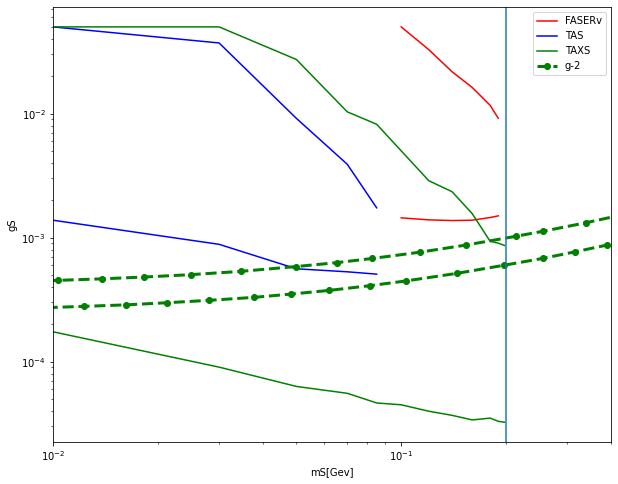

In [11]:
#home brewed contour plot

def makeplot(TAS,fig = '',ax = '',level = 3,label = '',color = 'k',nMC = 100):
    filename = 'Reach/event_space_%s.npz'%TAS;L = np.load(filename)
    event_space = L['event_space'];mS_array = L['mS_array'];gS_array = L['gS_array']
#     print('mshape:',np.shape(mS_array))
#     print('gshape:',np.shape(gS_array))
#     print('eventspace:',np.shape(event_space))
    if fig =='':
        fig,ax = plt.subplots(1,1,figsize = (10,8))

    glowerA = np.zeros(len(mS_array))
    gupperA = np.zeros(len(mS_array))

    for iim,m in enumerate(mS_array):
        gg = np.geomspace(np.min(gS_array),np.max(gS_array),1000)
        ES = np.interp(gg,gS_array,event_space[iim,:])
        critind = np.where(ES>level)
        if np.max(event_space[iim,:])<level:
            glowerA[iim] = np.nan;gupperA[iim]=np.nan
        else:
#             print(len(critind))
            lowerind,upperind = np.min(critind),np.max(critind)
            glower,gupper = gg[lowerind],gg[upperind]
            glowerA[iim] = glower;gupperA[iim]=gupper
    ax.plot(mS_array,glowerA,label = label,color = color)
    ax.plot(mS_array,gupperA,color = color)
    ax.set_yscale('log')
    ax.set_xscale('log')
    return fig,ax
def plotgm2(ax):
    filelower = 'muon_g-2_lower.txt'
    fileupper = 'muon_g-2_upper.txt'

    dfL = pd.read_csv(filelower,delim_whitespace=True,names = ['m','g'])
    dfU = pd.read_csv(fileupper,delim_whitespace=True,names = ['m','g'])

    ax.plot(dfL['m'] , dfL['g'],'go--',lw = 3)
    ax.plot(dfU['m'] , dfU['g'],'go--',lw = 3,label = 'g-2')


    
    ax.set_xlim(1e-2,400e-3)
    ax.axvline(x = 200e-3)
    ax.set_xlabel('mS[Gev]')
    ax.set_ylabel('gS')
    ax.legend()
    return fig, ax


    
target = 'FASER'
filename = '/media/maxfieg/Linux1/RoshanResearch/Reach_%s.pdf' %target
fig,ax = makeplot(target,level = 3,label = 'FASERv',color = 'r')

target = 'TAS'
fig,ax = makeplot(target,level = 3,label = 'TAS',color = 'b',fig = fig,ax = ax)

target = 'TAS2'
filename = '/media/maxfieg/Linux1/RoshanResearch/Reach_%s.pdf' %target
fig,ax = makeplot(target,level = 3,label = 'TAXS',color = 'g',fig = fig,ax = ax)

# fig,ax = makeplot('TAS',level = 3*(250/930),label = 'FASER Run3+Run4',fig = fig,ax = ax,color = 'blue')
plotgm2(ax)
# ax.text(10e-3,1e-3,'FASER2 Reach',fontsize = 20)
# fig,ax = makeplot('TAS',fig = fig,ax = ax)

mcent = np.array([10e-3,30e-3,50e-3,70e-3,85e-3,1e-1,1.2e-1,1.4e-1,1.6e-1,1.8e-1,1.9e-1,198e-3])
for m in mcent:
    

2700
76.64256432248894


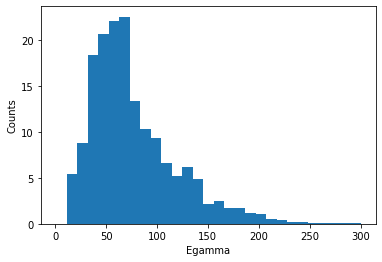

In [53]:
def get_photon_spectra():

    filename_proto = 'Reach/Kin_mS=8.50e-02MeV_gS=5.000e-04_event_array_TAS_nMC=2000_%d.npz'
    
    bins = np.linspace(1,300,30)
#     bins = 20
    Etotal = np.array([])
    Wtotal = np.array([])
    for ii in np.arange(5):
        filename = filename_proto %ii
#         np.savez(filename,mS = mS,gS = gS_array[iig],Nevents = event_array[iig],Egamma = Egamma[iig],x1=x1[iig],y1=y1[iig],x2=x2[iig],y2=y2[iig],weights=weights[iig])
        L = np.load(filename)
        E = L['Egamma'];W = L['weights'];N = L['Nevents']
        
        Etotal = np.append(Etotal,E)
        Wtotal = np.append(Wtotal,W)
        
    print(len(Etotal))
    plt.hist(Etotal,weights = Wtotal,bins = bins)
    print(np.sum(Etotal*Wtotal) / np.sum(Wtotal))
    plt.xlabel('Egamma')
    plt.ylabel('Counts')
get_photon_spectra()
#0.085 0.0005

In [ ]:
Reach/Kin_mS=8.50e-02MeV_gS=5.000e-04_event_array_TAS_nMC=2000_0.npz
Reach/Kin_mS=8.50e-02MeV_gS=5e-04_event_array_TAS_nMC=2000_0.npz

In [103]:
def make_color_plot(fig='',ax=''):
    fig,ax = plt.subplots(1,1,figsize = (10,8))
    
    plt.rcParams.update({'font.size':10})
    filename = '/media/maxfieg/Linux1/RoshanResearch/Reach/event_space_%s.npz'%TAS;L = np.load(filename)
    event_space = L['event_space'];mS_array = L['mS_array'];gS_array = L['gS_array']
    H = ax.imshow(event_space.T, origin='lower', cmap='viridis', aspect='auto',extent=[mS_array[0], mS_array[-1], gS_array[0], gS_array[-1]])
    ax.set_yscale('log')
    plt.colorbar(H,cax = ax)
    ax.set_xscale('log')
    return fig,ax
fig,ax = make_color_plot(fig,ax)
# fig,ax = makeplot('TAS',level = 3,label = 'FASER Run3',color = 'k',fig = fig,ax = ax)
# fig,ax = makeplot('TAS',level = 3*(250/930),label = 'FASER Run3+Run4',fig = fig,ax = ax,color = 'blue')

/tmp/ipykernel_16097/1305442540.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.colorbar(H,cax = ax)


<Figure size 432x288 with 0 Axes>

# Now get photon spectra

# Serial

In [38]:
#this is after removing extra TAS
def get_N_array(mS,gS_array):
    event_array = np.zeros_like(gS_array)
    for iig,gS in enumerate(gS_array):
        eventrate = EmuonLoop(mS,gS,'TAS',verbose = True,nMC = 2)
        event_array[iig] = eventrate
    return event_array
mS = 100e-3
# gS_array = np.geomspace(1e-4,4.48e-03,7)
gS_array = 1.26e-03 * np.ones(1)

event_array = get_N_array(mS,gS_array)

nMC is: 2
For emuon = 105.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 205.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 305.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 405.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 505.00 , rate here = 0.00e+00, total rate = 0.00e+00
For emuon = 605.00 , rate here = 0.00e+00, total rate = 0.00e+00


KeyboardInterrupt: 

In [6]:
#This is with S rotation
def get_N_array(mS,gS_array):
    event_array = np.zeros_like(gS_array)
    for iig,gS in enumerate(gS_array):
        eventrate = EmuonLoop(mS,gS,'TAS',verbose = False,nMC = 3000)
        event_array[iig] = eventrate
    return event_array
mS = 100e-3
gS_array = np.geomspace(1e-4,4.48e-03,7)
# gS_array = 1.26e-03 * np.ones(1)
event_array = get_N_array(mS,gS_array)
filename = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/mS=100MeV_events.txt'
print(event_array)
filename = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/mS=100MeV_events.txt'
A = np.array([gS,event_array]).T
np.savetxt(filename,A)

nMC is: 3000
For emuon = 105.00 , rate here = 6.61e-04, total rate = 3.02e-02
For emuon = 205.00 , rate here = 5.87e-05, total rate = 3.27e-02
For emuon = 305.00 , rate here = 2.81e-05, total rate = 3.30e-02
For emuon = 405.00 , rate here = 0.00e+00, total rate = 3.31e-02
For emuon = 505.00 , rate here = 2.78e-06, total rate = 3.31e-02
For emuon = 605.00 , rate here = 1.23e-06, total rate = 3.31e-02
For emuon = 725.00 , rate here = 0.00e+00, total rate = 3.31e-02
Breaking out. emuon=925.00, emuon_max = 25.00, ratehere = 0.00, maxrate = 0.01, total=0.03, mS = 0.10, gS = 1.00e-04
##########
nMC is: 3000
For emuon = 105.00 , rate here = 7.98e-03, total rate = 2.79e-01
For emuon = 205.00 , rate here = 2.61e-03, total rate = 3.09e-01
For emuon = 305.00 , rate here = 1.33e-04, total rate = 3.15e-01
For emuon = 405.00 , rate here = 0.00e+00, total rate = 3.16e-01
For emuon = 505.00 , rate here = 4.93e-05, total rate = 3.16e-01
For emuon = 605.00 , rate here = 4.38e-06, total rate = 3.16e-01
F

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [5]:
filename = '/media/maxfieg/Linux1/RoshanResearch/MuonSim/mS=100MeV_events.txt'

event_array = np.array([0.0331336 , 0.31638255, 1.12524327 ,3.3488789  ,2.20797266, 0.20886482,0])
gS_array = np.geomspace(1e-4,4.48e-03,7)

A = np.array([gS_array,event_array]).T
np.savetxt(filename,A)

print(A)

[[1.00000000e-04 3.31336000e-02]
 [1.88457316e-04 3.16382550e-01]
 [3.55161601e-04 1.12524327e+00]
 [6.69328021e-04 3.34887890e+00]
 [1.26139763e-03 2.20797266e+00]
 [2.37719611e-03 2.08864820e-01]
 [4.48000000e-03 0.00000000e+00]]


# now plot

Text(0.5, 1.0, 'mS = 100 MeV @ FASER 1')

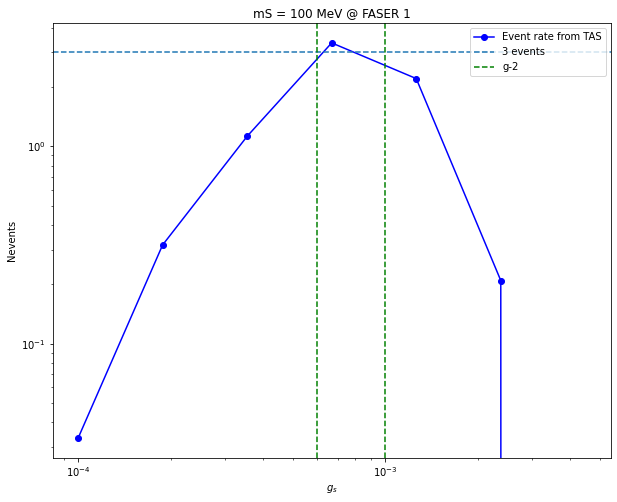

In [2]:
plt.rcParams.update({'font.size':15})
fig , ax = plt.subplots(1,1,figsize = (10,8))
event_array = [0.0331336 , 0.31638255, 1.12524327 ,3.3488789  ,2.20797266, 0.20886482,0]
gS_array = np.geomspace(1e-4,4.48e-03,7)
ax.plot(gS_array , event_array,'bo-',label = 'Event rate from TAS')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$g_s$')
ax.set_ylabel('Nevents')
ax.axhline(y = 3,label = '3 events',ls = 'dashed')

#g-2
ax.axvline(x = 6e-4,ls = 'dashed',color = 'green',label = 'g-2')
ax.axvline(x = 10e-4,ls = 'dashed',color = 'green')
ax.legend()
ax.set_title('mS = 100 MeV @ FASER 1')

Text(0.5, 1.0, 'mS = 100 MeV @ FASER 1')

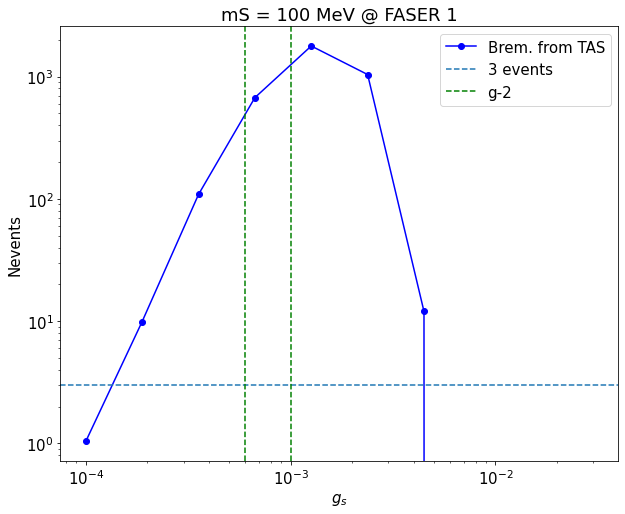

In [69]:
plt.rcParams.update({'font.size':15})
fig , ax = plt.subplots(1,1,figsize = (10,8))
ax.plot(gS_array , event_array,'bo-',label = 'Event rate from TAS')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$g_s$')
ax.set_ylabel('Nevents')
ax.axhline(y = 3,label = '3 events',ls = 'dashed')

#g-2
ax.axvline(x = 6e-4,ls = 'dashed',color = 'green',label = 'g-2')
ax.axvline(x = 10e-4,ls = 'dashed',color = 'green')
ax.legend()
ax.set_title('mS = 100 MeV @ FASER 1')

# is beam rotation done correctly?

In [ ]:
E = 100;
m = 100e-3
eta = np.inf
phi = 0
p = pyl.Momentum4.e_m_eta_phi(E,m,eta,phi)
print('before (E,px,py,pz)',p.e,p.p_x,p.p_y,p.p_z)
p.r